# Laboratorio 1: Series de Tiempo — AVANCE
**CC3084 – Data Science | UVG | Semestre II 2026**
Jonathan Zacarias 231104

**Dataset:** Ingreso de viajeros internacionales a Guatemala (enero 2009 – junio 2026)

Este notebook contiene el **avance** solicitado para el 23 de julio de 2026 (17:20):
1. Análisis exploratorio de datos (EDA) completo.
2. División del conjunto en entrenamiento (70%) y prueba (30%).
3. Construcción de las series de tiempo mensuales (serie obligatoria + dos categorías: **Vías de ingreso** y **Tipo de viajero**).
4. Análisis detallado (incisos a–e del enunciado) de **dos series**: Total mensual y Vía Aérea.

El resto de series, la selección/ajuste de modelos (ARIMA, Prophet, Holt-Winters, suavizamiento exponencial, seasonal naive), las métricas de predicción (MAE, RMSE, AIC, BIC) y el análisis comparativo final se completarán en el documento final del 26 de julio de 2026.

**Nota sobre los datos** (según hoja "Notas" del archivo fuente): el conjunto combina tres tramos con metodologías distintas (2009–2020 respaldos históricos, 2021–2022 entrega del IGM, 2023–jun. 2026 sistema depurado del INGUAT). Existe un **quiebre metodológico entre 2022 y 2023** que reduce artificialmente la categoría "Viajero" (comercio fronterizo/tránsito) sin que represente una caída real de turismo. Para comparar todo el período se recomienda usar **Turista + Excursionista**.


## 0. Configuración e importación de librerías

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
TEAL = "#0B7285"

MESES = {'Ene':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,
         'Jul':7,'Ago':8,'Sep':9,'Oct':10,'Nov':11,'Dic':12}

## 1. Carga de datos

In [7]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx", sheet_name="Datos")
df["Mes_num"] = df["Mes"].map(MESES)
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes_num"], day=1))

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (161036, 15)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Mes_num,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,1,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,1,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,1,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,1,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,1,2009-01-01


In [8]:
df.dtypes

Año                               int64
Mes cod                           int64
Mes                                 str
Vía                                 str
Frontera                            str
País                                str
Región                              str
Región dos                          str
Regiones OMT                        str
MCEO                                str
Agrupación Residencia               str
Tipo de Viajero                     str
Viajero                         float64
Mes_num                           int64
Fecha                    datetime64[us]
dtype: object

## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Valores faltantes, duplicados y valores atípicos

In [9]:
print("Valores faltantes por columna:")
print(df.isna().sum())
print("\nFilas duplicadas exactas:", df.duplicated().sum())
print("Valores negativos en 'Viajero':", (df["Viajero"] < 0).sum())
print("Valores en cero en 'Viajero':", (df["Viajero"] == 0).sum(),
      f"({(df['Viajero']==0).mean():.2%})")

Valores faltantes por columna:
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
Mes_num                  0
Fecha                    0
dtype: int64

Filas duplicadas exactas: 0
Valores negativos en 'Viajero': 0
Valores en cero en 'Viajero': 54 (0.03%)


El conjunto **no tiene valores nulos ni filas duplicadas**. Hay 54 registros en cero (0.03%), consistentes con combinaciones categóricas de muy baja frecuencia, no con errores de carga.

In [10]:
q1, q3 = df["Viajero"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 3 * iqr
outliers = (df["Viajero"] > upper).sum()
print(f"Registros sobre el límite superior IQR (k=3): {outliers} ({outliers/len(df):.2%})")
df["Viajero"].describe()

Registros sobre el límite superior IQR (k=3): 21104 (13.11%)


count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

A nivel de **registro de detalle**, ~13% de las filas quedan marcadas como atípicas por un criterio IQR, pero esto es **esperado y no es un error**: la columna 'Viajero' mezcla flujos muy heterogéneos en la misma columna (p. ej. la frontera '01 La Aurora' o el tipo 'Turista' concentran volúmenes muy superiores a fronteras pequeñas o al tipo 'Cruceristas'). La gran dispersión (media 324.7 vs. mediana 7.0) confirma una distribución muy asimétrica a la derecha. Los atípicos "reales" se evaluarán sobre las **series agregadas mensuales** (nivel de modelado), no sobre el detalle.

### 2.2 Comportamiento temporal del número de viajeros

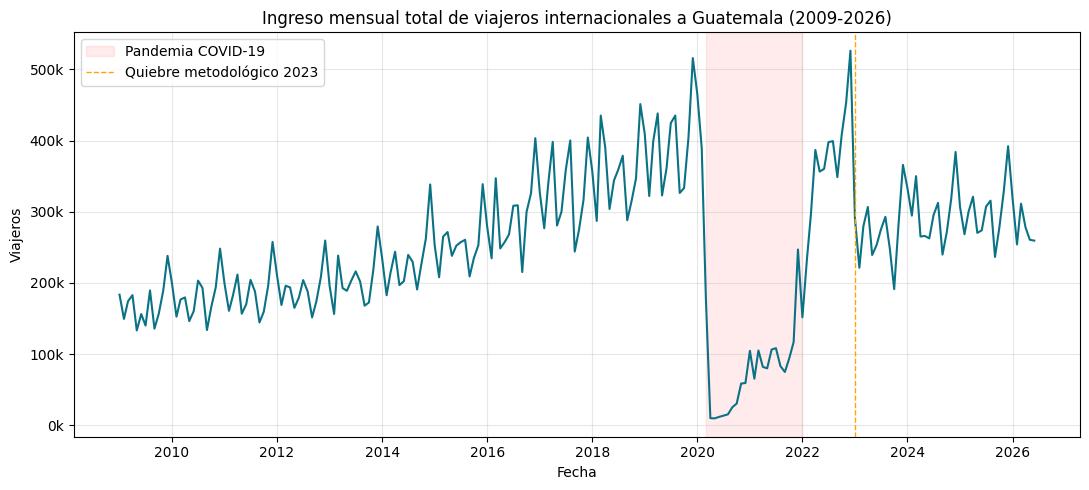

In [11]:
serie_total = df.groupby("Fecha")["Viajero"].sum().sort_index()

fig, ax = plt.subplots()
ax.plot(serie_total.index, serie_total.values, color=TEAL)
ax.set_title("Ingreso mensual total de viajeros internacionales a Guatemala (2009-2026)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}k"))
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.08, label="Pandemia COVID-19")
ax.axvline(pd.Timestamp("2023-01-01"), color="orange", linestyle="--", linewidth=1, label="Quiebre metodológico 2023")
ax.legend()
plt.tight_layout(); plt.show()

La serie muestra una **tendencia creciente** entre 2009 y 2019, un **colapso abrupto** en marzo de 2020 por la pandemia (zona roja), un piso prolongado en 2020–2021, y una **recuperación marcada** desde 2022. La línea naranja punteada (enero 2023) marca el quiebre metodológico documentado en las notas del dataset.

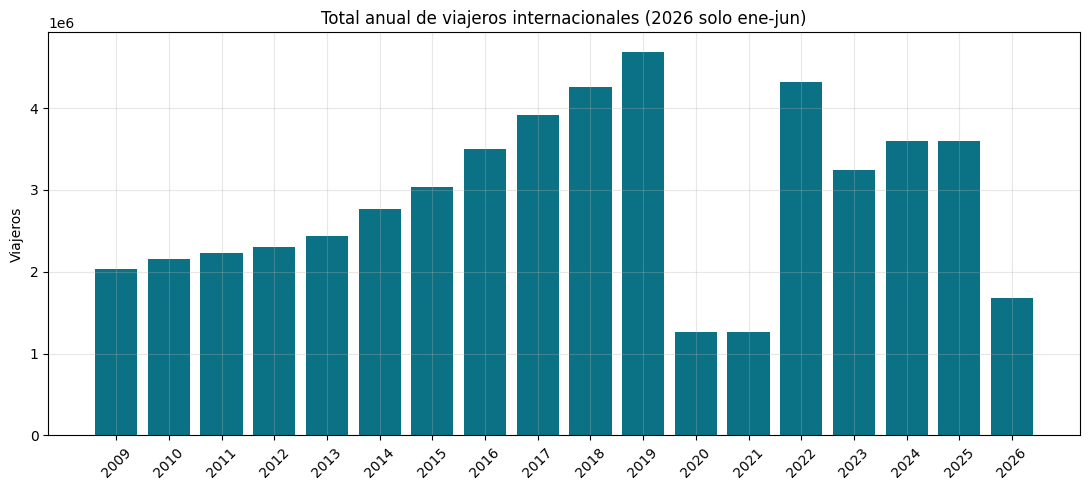

Año
2009    2.028776e+06
2010    2.152899e+06
2011    2.231456e+06
2012    2.299816e+06
2013    2.432169e+06
2014    2.762602e+06
2015    3.041643e+06
2016    3.496217e+06
2017    3.921460e+06
2018    4.256349e+06
2019    4.691820e+06
2020    1.266340e+06
2021    1.267768e+06
2022    4.316164e+06
2023    3.248709e+06
2024    3.593876e+06
2025    3.597238e+06
2026    1.682636e+06
Name: Viajero, dtype: float64

In [12]:
anual = df.groupby("Año")["Viajero"].sum()
fig, ax = plt.subplots()
ax.bar(anual.index.astype(str), anual.values, color=TEAL)
ax.set_title("Total anual de viajeros internacionales (2026 solo ene-jun)")
ax.set_ylabel("Viajeros"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
anual

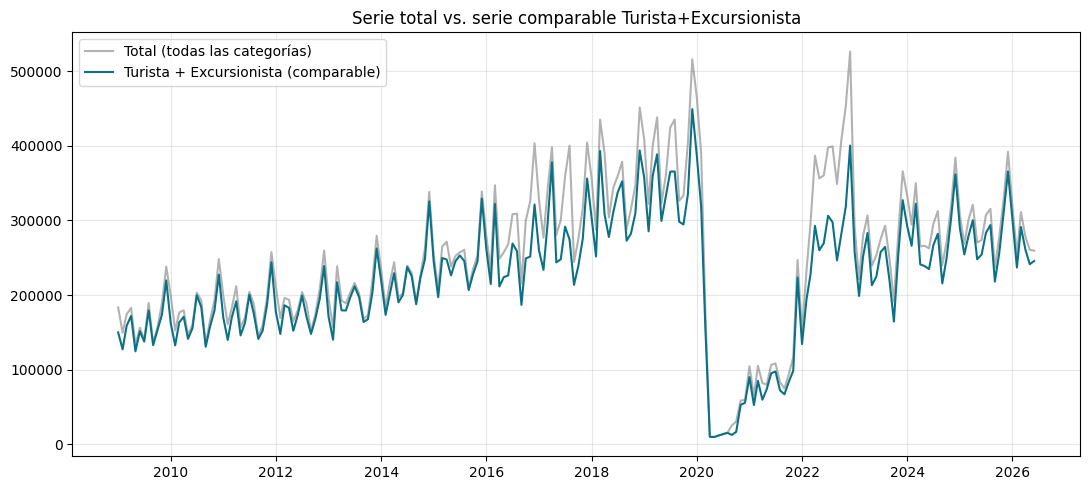

In [13]:
df_comp = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]
serie_comp = df_comp.groupby("Fecha")["Viajero"].sum().sort_index()

fig, ax = plt.subplots()
ax.plot(serie_total.index, serie_total.values, label="Total (todas las categorías)", color="grey", alpha=0.6)
ax.plot(serie_comp.index, serie_comp.values, label="Turista + Excursionista (comparable)", color=TEAL)
ax.set_title("Serie total vs. serie comparable Turista+Excursionista")
ax.legend(); plt.tight_layout(); plt.show()

Al comparar ambas series se confirma que la brecha entre el 'Total' y 'Turista+Excursionista' se **amplía antes de 2023** (por el peso de la categoría 'Viajero' de comercio fronterizo/tránsito) y se **reduce después de 2023**, validando la recomendación de usar la serie comparable para analizar la tendencia de largo plazo en turismo.

**Comportamiento durante y después de la pandemia:** el ingreso total cae de 4.69M de viajeros en 2019 a 1.27M en 2020 (–73%) y se mantiene en un piso similar en 2021. La recuperación es rápida en 2022 (4.32M), aunque en parte impulsada por el cambio metodológico. 2023–2025 se estabiliza entre 3.2M y 3.6M anuales bajo la nueva metodología depurada del INGUAT.

### 2.3 Países con mayor cantidad de viajeros

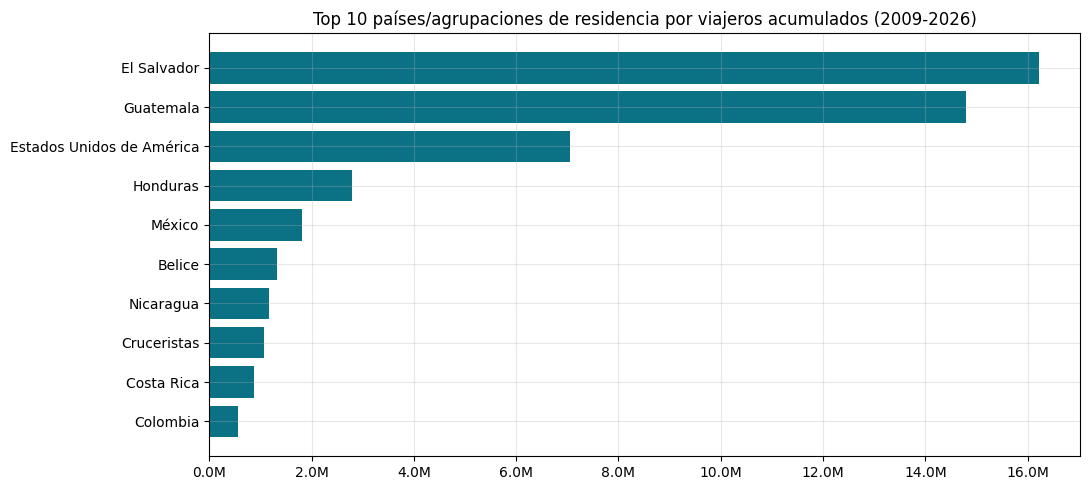

País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
México                       1.808946e+06
Belice                       1.328256e+06
Nicaragua                    1.164343e+06
Cruceristas                  1.078372e+06
Costa Rica                   8.821797e+05
Colombia                     5.610353e+05
Name: Viajero, dtype: float64

In [14]:
top_paises = df.groupby("País")["Viajero"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
ax.barh(top_paises.index[::-1], top_paises.values[::-1], color=TEAL)
ax.set_title("Top 10 países/agrupaciones de residencia por viajeros acumulados (2009-2026)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()
top_paises

El Salvador (16.2M) y Guatemala (14.8M — viajeros identificados con residencia en el propio país, usualmente comercio/tránsito fronterizo) encabezan el acumulado, seguidos de Estados Unidos (7.0M), Honduras (2.8M) y México (1.8M). El dominio de países vecinos centroamericanos es consistente con el peso de la vía terrestre.

### 2.4 Regiones con mayor cantidad de viajeros

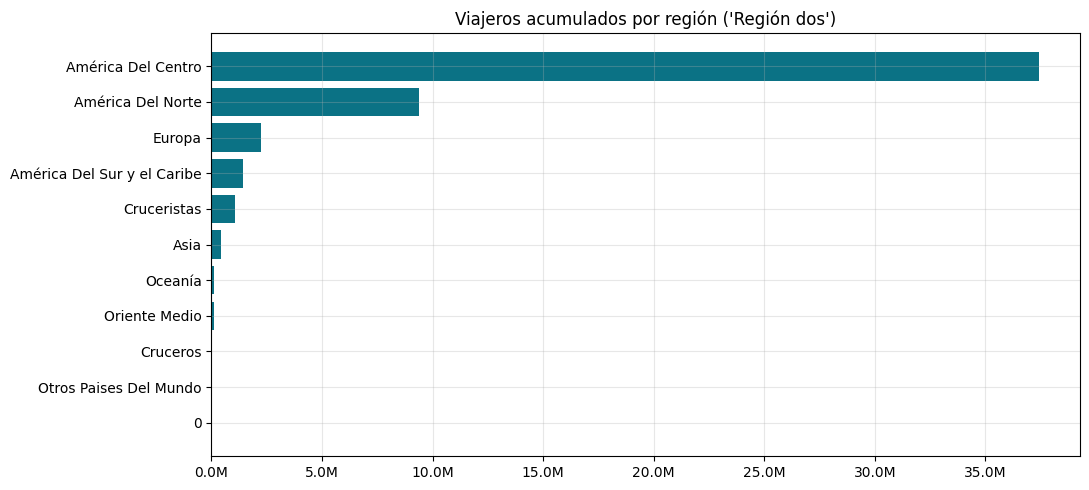

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.078372e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Cruceros                       2.603000e+04
Otros Paises Del Mundo         2.511115e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

In [15]:
top_regiones = df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.barh(top_regiones.index[::-1], top_regiones.values[::-1], color=TEAL)
ax.set_title("Viajeros acumulados por región ('Región dos')")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()
top_regiones

América del Centro concentra 37.4M de viajeros acumulados (~74% del total), seguida por América del Norte (9.4M) y Europa (2.2M). El turismo/tránsito hacia Guatemala es predominantemente **intrarregional**, con Norteamérica como principal mercado de largo alcance.

### 2.5 Vías de ingreso y fronteras más utilizadas

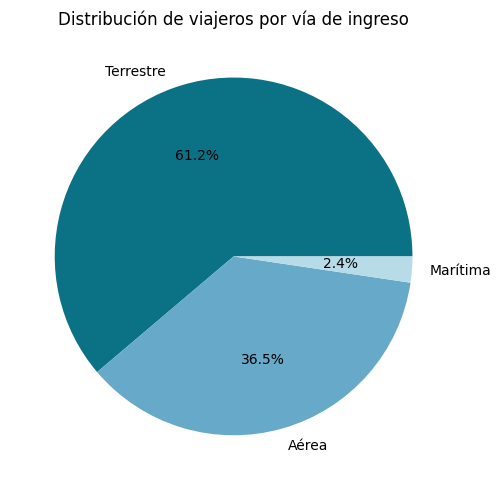

Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64

In [16]:
via = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.pie(via.values, labels=via.index, autopct="%1.1f%%", colors=["#0B7285","#66A9C9","#B7DCE8"])
ax.set_title("Distribución de viajeros por vía de ingreso")
plt.tight_layout(); plt.show()
via

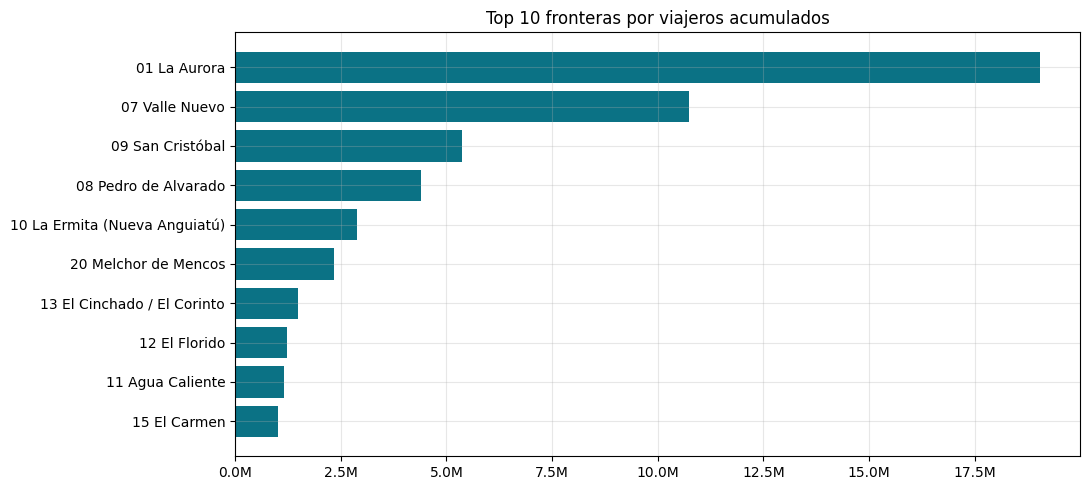

Frontera
01 La Aurora                     1.903440e+07
07 Valle Nuevo                   1.073234e+07
09 San Cristóbal                 5.363009e+06
08 Pedro de Alvarado             4.393577e+06
10 La Ermita (Nueva Anguiatú)    2.879210e+06
20 Melchor de Mencos             2.349551e+06
13 El Cinchado / El Corinto      1.497006e+06
12 El Florido                    1.221040e+06
11 Agua Caliente                 1.154542e+06
15 El Carmen                     1.023092e+06
Name: Viajero, dtype: float64

In [17]:
top_fronteras = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
ax.barh(top_fronteras.index[::-1], top_fronteras.values[::-1], color=TEAL)
ax.set_title("Top 10 fronteras por viajeros acumulados")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()
top_fronteras

La vía **Terrestre** concentra el 61.4% de los viajeros (32.0M), seguida por la **Aérea** (36.6%, 19.1M) y, muy por debajo, la **Marítima** (2.4%, 1.2M) — coherente con la nota del dataset de que la vía Marítima pierde detalle de registro desde 2017.

El aeropuerto **La Aurora** es el punto de ingreso más importante (19.0M), seguido de las fronteras terrestres **Valle Nuevo** con El Salvador (10.7M) y **San Cristóbal** con Honduras (5.4M). Estas tres fronteras concentran cerca del 68% del total acumulado.

### 2.6 Tipo de viajero

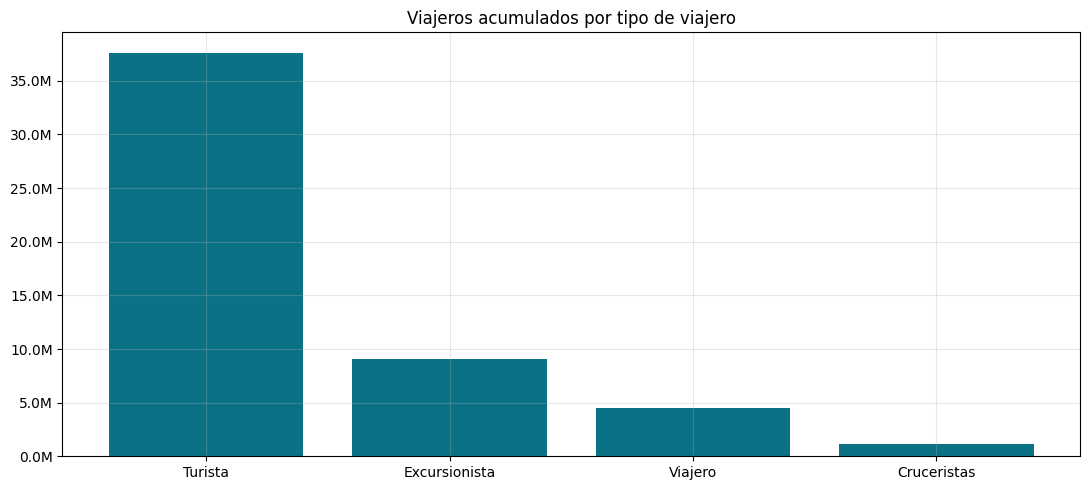

Tipo de Viajero
Turista          3.764273e+07
Excursionista    9.069184e+06
Viajero          4.471622e+06
Cruceristas      1.104402e+06
Name: Viajero, dtype: float64

In [18]:
tipo = df.groupby("Tipo de Viajero")["Viajero"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.bar(tipo.index, tipo.values, color=TEAL)
ax.set_title("Viajeros acumulados por tipo de viajero")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()
tipo

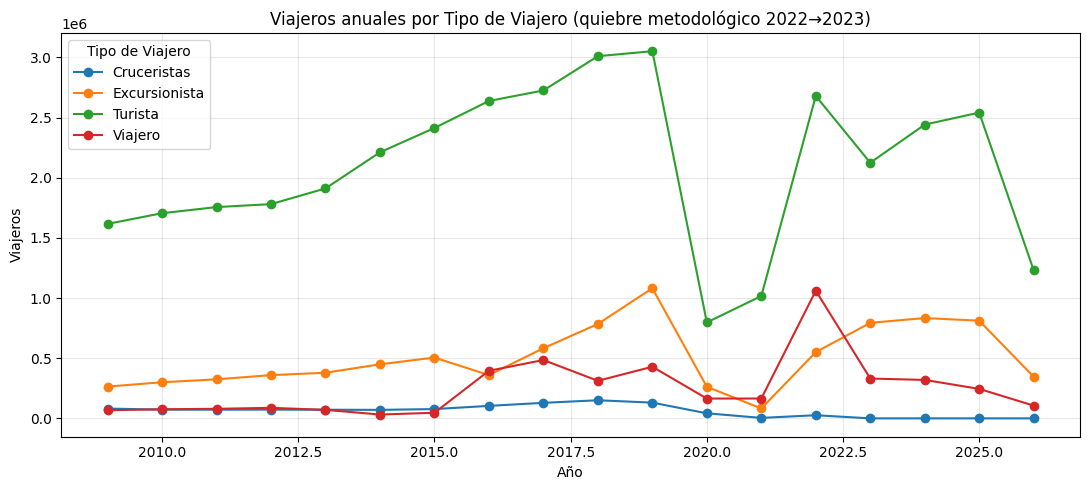

In [19]:
tipo_anual = df.pivot_table(index="Año", columns="Tipo de Viajero", values="Viajero", aggfunc="sum").fillna(0)
fig, ax = plt.subplots()
tipo_anual.plot(ax=ax, marker="o")
ax.set_title("Viajeros anuales por Tipo de Viajero (quiebre metodológico 2022→2023)")
ax.set_ylabel("Viajeros")
plt.tight_layout(); plt.show()

'Turista' domina el acumulado (37.6M), seguido de 'Excursionista' (9.1M), 'Viajero' (4.5M) y 'Cruceristas' (1.1M, que solo se registra hasta 2022). El gráfico anual evidencia con claridad la **caída abrupta de la categoría 'Viajero' en 2023**, confirmando estadísticamente la advertencia del dataset sobre el cambio de criterio de clasificación.